# GRAPE NFW Baryon Density Profiles from Simulation Data

This notebook demonstrates the use of `GrapeNFWProfile` to compute baryon density profiles using $f_b$ functions derived from cosmological simulations. We use interpolators from `utils.py` to create smooth $f_b(r)$ functions for SIMBA, EAGLE, TNG, and CROCODILE simulations across all available halo mass bins.

The GRAPE framework models baryon density as:
$$\rho_B(r) = \frac{\Omega_b}{\Omega_m - \Omega_b} \left[ g(r) \rho_{DM}(r) + \frac{1}{4\pi r^2} \frac{dg}{dr} M_{DM}(<r) \right]$$

where $g(r) = \frac{f_b(r)}{(1-f_b(r)) \Omega_{ratio}}$

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from pathlib import Path
from astropy.table import Table

# Import from grapes package
from grapes import GrapeNFWProfile, create_A23_interpolators, create_crocodile_interpolators
from grapes.defs import cosmo

# Plotting configuration
plt.rcParams.update({'font.size': 12, 'figure.dpi': 100})
plt.rcParams['axes.linewidth'] = 1.5

# Constants and setup
R_PLOT_RANGE = np.logspace(-2, 1.5, 300)  # Normalized radius y = r/r_s
CONCENTRATION = 1
REDSHIFT = 0.0

## Load Simulation Data Tables

In [29]:
# Locate data files
import importlib.resources
from pathlib import Path

data_dir = Path(importlib.resources.files('grapes').joinpath('data'))

# Ayromlou+2023 data files
ayromlou_files = {
    'TNG': data_dir / 'Ayromlou2023a_Fig2_TNG.txt',
    'SIMBA': data_dir / 'Ayromlou2023a_Fig2_SIMBA.txt',
    'EAGLE': data_dir / 'Ayromlou2023b_Fig2_EAGLE.txt'
}

# CROCODILE data files
crocodile_files = {
    'CROCODILE': data_dir / 'Zhao_Zhang_CROCODILE.txt'
}

# Load Ayromlou tables with explicit column names
ayromlou_tables = {}
for sim_name, filepath in ayromlou_files.items():
    print(f"\nLoading {sim_name} data from {filepath}")
    ayromlou_tables[sim_name] = Table.read(
        filepath,
        format='ascii',
        names=['model_index', 'halo_mass_index', 'halo_mass_bin_value', 'x=R/R200c', 'y=f_b(<R)/f_b,cosmic']
    )
    mask = np.isfinite(ayromlou_tables[sim_name]['x=R/R200c']) & np.isfinite(ayromlou_tables[sim_name]['y=f_b(<R)/f_b,cosmic'])
    ayromlou_tables[sim_name] = ayromlou_tables[sim_name][mask]
    print(f"  Columns: {ayromlou_tables[sim_name].colnames}")
    print(f"  Unique halo_mass_index values: {np.unique(ayromlou_tables[sim_name]['halo_mass_index'])}")

# Load CROCODILE table with explicit column names
print(f"\nLoading CROCODILE data from {crocodile_files['CROCODILE']}")
crocodile_table = Table.read(
    crocodile_files['CROCODILE'],
    format='ascii',
    names=['logM_lo', 'logM_up', 'label_AGN', 'R_over_R200', 'fb_med_norm', 'fb_lo_norm', 'fb_hi_norm']
)
print(f"  Columns: {crocodile_table.colnames}")
print(f"  Unique logM_lo values: {np.unique(crocodile_table['logM_lo'])}")
print(f"  Available AGN labels: {np.unique(crocodile_table['label_AGN'])}")


Loading TNG data from /home/sunil/Python/grapes/grapes/data/Ayromlou2023a_Fig2_TNG.txt
  Columns: ['model_index', 'halo_mass_index', 'halo_mass_bin_value', 'x=R/R200c', 'y=f_b(<R)/f_b,cosmic']
  Unique halo_mass_index values: [0 1 2 3 4 5 6]

Loading SIMBA data from /home/sunil/Python/grapes/grapes/data/Ayromlou2023a_Fig2_SIMBA.txt
  Columns: ['model_index', 'halo_mass_index', 'halo_mass_bin_value', 'x=R/R200c', 'y=f_b(<R)/f_b,cosmic']
  Unique halo_mass_index values: [2 3 4 5 6]

Loading EAGLE data from /home/sunil/Python/grapes/grapes/data/Ayromlou2023b_Fig2_EAGLE.txt
  Columns: ['model_index', 'halo_mass_index', 'halo_mass_bin_value', 'x=R/R200c', 'y=f_b(<R)/f_b,cosmic']
  Unique halo_mass_index values: [0 1 2 3 4 5 6]

Loading CROCODILE data from /home/sunil/Python/grapes/grapes/data/Zhao_Zhang_CROCODILE.txt
  Columns: ['logM_lo', 'logM_up', 'label_AGN', 'R_over_R200', 'fb_med_norm', 'fb_lo_norm', 'fb_hi_norm']
  Unique logM_lo values: logM_lo
-------
    9.0
   10.0
   11.0
   12

In [30]:
# Extract original x-axis data points (r/r_s) for each simulation and mass bin
print("\n" + "="*60)
print("Extracting original data point x-values (r/r_s)...")
print("="*60)

# For Ayromlou simulations: x=R/R200c, convert to r/r_s
ayromlou_original_x = {}
for sim_name, table in ayromlou_tables.items():
    print(f"\n{sim_name}:")
    ayromlou_original_x[sim_name] = {}
    
    unique_indices = np.unique(table['halo_mass_index'])
    for halo_idx in unique_indices:
        mask = table['halo_mass_index'] == halo_idx
        # Convert R/R200c to r/r_s using r_s = r_200/concentration
        # So r/r_s = (r/r_200) * concentration
        r_over_rs = table['x=R/R200c'][mask] * CONCENTRATION
        ayromlou_original_x[sim_name][halo_idx] = np.array(r_over_rs)
        print(f"  halo_mass_index={halo_idx}: {len(r_over_rs)} data points")

# For CROCODILE: R_over_R200, convert to r/r_s
crocodile_original_x = {}
for agn_label in ['f', 'n']:
    label_str = 'fiducial' if agn_label == 'f' else 'no-AGN'
    print(f"\nCROCODILE ({label_str}):")
    crocodile_original_x[agn_label] = {}
    
    unique_logM = np.unique(crocodile_table['logM_lo'])
    for logM in unique_logM:
        mask = (crocodile_table['logM_lo'] == logM) & (crocodile_table['label_AGN'] == agn_label)
        # Convert R/R200 to r/r_s
        r_over_rs = crocodile_table['R_over_R200'][mask] * CONCENTRATION
        crocodile_original_x[agn_label][float(logM)] = np.array(r_over_rs)
        print(f"  logM={float(logM):.2f}: {len(r_over_rs)} data points")


Extracting original data point x-values (r/r_s)...

TNG:
  halo_mass_index=0: 100 data points
  halo_mass_index=1: 100 data points
  halo_mass_index=2: 100 data points
  halo_mass_index=3: 100 data points
  halo_mass_index=4: 100 data points
  halo_mass_index=5: 100 data points
  halo_mass_index=6: 100 data points

SIMBA:
  halo_mass_index=2: 100 data points
  halo_mass_index=3: 100 data points
  halo_mass_index=4: 100 data points
  halo_mass_index=5: 100 data points
  halo_mass_index=6: 100 data points

EAGLE:
  halo_mass_index=0: 100 data points
  halo_mass_index=1: 100 data points
  halo_mass_index=2: 100 data points
  halo_mass_index=3: 100 data points
  halo_mass_index=4: 100 data points
  halo_mass_index=5: 100 data points
  halo_mass_index=6: 100 data points

CROCODILE (fiducial):
  logM=9.00: 180 data points
  logM=10.00: 180 data points
  logM=11.00: 180 data points
  logM=12.00: 180 data points
  logM=13.00: 180 data points
  logM=14.00: 180 data points

CROCODILE (no-AGN):


## Build $f_b(r)$ Interpolators from Simulation Data

In [31]:
# Define the radius scale as the default value of the concentration parameter
f_b_radius_scale = CONCENTRATION

# Create f_b interpolators for Ayromlou simulations using CubicSpline
a23_interpolators = {}
for sim_name, table in ayromlou_tables.items():
    print(f"\nCreating interpolators for {sim_name}...")
    a23_interpolators[sim_name] = create_A23_interpolators(
        table,
        interpolator_type='CubicSpline'
    )
    print(f"  Created {len(a23_interpolators[sim_name])} interpolators with CubicSpline")

# Create f_b interpolators for CROCODILE data (both AGN labels) using Akima1DInterpolator
crocodile_interpolators = {}
for agn_label in ['f', 'n']:
    label_str = 'fiducial' if agn_label == 'f' else 'no-AGN'
    print(f"\nCreating CROCODILE interpolators for AGN_label={agn_label} ({label_str})...")
    crocodile_interpolators[agn_label] = create_crocodile_interpolators(
        crocodile_table, 
        AGN_label=agn_label,
        interpolator_type='Akima1DInterpolator',
        spline_args={'method': 'makima'}
    )
    print(f"  Created {len(crocodile_interpolators[agn_label])} interpolators with Akima1DInterpolator (makima)")

# Print summary
print("\n" + "="*60)
print("Interpolator Summary:")
print("="*60)
for sim_name in a23_interpolators:
    print(f"{sim_name}: {sorted(a23_interpolators[sim_name].keys())}")
for agn_label in crocodile_interpolators:
    label_str = 'fiducial' if agn_label == 'f' else 'no-AGN'
    print(f"CROCODILE ({label_str}): {sorted(crocodile_interpolators[agn_label].keys())}")


Creating interpolators for TNG...
  Created 7 interpolators with CubicSpline

Creating interpolators for SIMBA...
  Created 5 interpolators with CubicSpline

Creating interpolators for EAGLE...
  Created 7 interpolators with CubicSpline

Creating CROCODILE interpolators for AGN_label=f (fiducial)...
  Created 6 interpolators with Akima1DInterpolator (makima)

Creating CROCODILE interpolators for AGN_label=n (no-AGN)...
  Created 6 interpolators with Akima1DInterpolator (makima)

Interpolator Summary:
TNG: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
SIMBA: [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
EAGLE: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
CROCODILE (fiducial): [np.float64(9.0), np.float64(10.0), np.float64(11.0), np.float64(12.0), np.float64(13.0), np.float64(14.0)]
CROCODILE (no-AGN): [np.float64(9.0), np.float64(10.0), np.float64(11.0), np.float64(12.0), np

## Construct GrapeNFWProfile Objects for All Halo-Mass Bins

In [32]:
# Create GRAPE profiles for Ayromlou simulations
grape_profiles = {}

for sim_name in a23_interpolators:
    print(f"\nCreating GrapeNFWProfile objects for {sim_name}...")
    grape_profiles[sim_name] = {}
    
    for halo_mass_idx, f_b_interp in a23_interpolators[sim_name].items():
        # Get the halo mass from the table
        mask = ayromlou_tables[sim_name]['halo_mass_index'] == halo_mass_idx
        halo_mass_value = float(ayromlou_tables[sim_name]['halo_mass_bin_value'][mask][0])
        
        try:
            # Create wrapper function for the interpolator
            def make_f_b_func(interp):
                def f_b_func(r):
                    return interp(r)
                return f_b_func
            
            f_b_func = make_f_b_func(f_b_interp)
            
            # Create GrapeNFWProfile
            profile = GrapeNFWProfile(
                log_M_halo_dm=halo_mass_value,
                f_b_func=f_b_func,
                concentration=CONCENTRATION,
                redshift=REDSHIFT,
                cosmology=cosmo
            )
            
            grape_profiles[sim_name][halo_mass_idx] = {
                'profile': profile,
                'log_M_halo': halo_mass_value,
                'halo_mass_idx': halo_mass_idx
            }
            print(f"  ✓ Created profile for halo_mass_index={halo_mass_idx}, log10(M)={halo_mass_value:.2f}")
        except Exception as e:
            print(f"  ✗ Failed for halo_mass_index={halo_mass_idx}: {e}")

# Create GRAPE profiles for CROCODILE
print("\n" + "="*60)
print("Creating GrapeNFWProfile objects for CROCODILE...")
print("="*60)

crocodile_grape_profiles = {}
for agn_label in ['f', 'n']:
    label_str = 'fiducial' if agn_label == 'f' else 'no-AGN'
    print(f"\nCROCODILE ({label_str}):")
    crocodile_grape_profiles[agn_label] = {}
    
    for logM, f_b_interp in crocodile_interpolators[agn_label].items():
        try:
            def make_f_b_func(interp):
                def f_b_func(r):
                    return interp(r)
                return f_b_func
            
            f_b_func = make_f_b_func(f_b_interp)
            
            profile = GrapeNFWProfile(
                log_M_halo_dm=float(logM),
                f_b_func=f_b_func,
                concentration=CONCENTRATION,
                redshift=REDSHIFT,
                cosmology=cosmo
            )
            
            crocodile_grape_profiles[agn_label][float(logM)] = {
                'profile': profile,
                'log_M_halo': float(logM),
                'logM': float(logM)
            }
            print(f"  ✓ Created profile for logM={float(logM):.2f}")
        except Exception as e:
            print(f"  ✗ Failed for logM={logM}: {e}")
            import traceback
            traceback.print_exc()


Creating GrapeNFWProfile objects for TNG...
  ✓ Created profile for halo_mass_index=0, log10(M)=8.00
  ✓ Created profile for halo_mass_index=1, log10(M)=9.00
  ✓ Created profile for halo_mass_index=2, log10(M)=10.00
  ✓ Created profile for halo_mass_index=3, log10(M)=11.00
  ✓ Created profile for halo_mass_index=4, log10(M)=12.00
  ✓ Created profile for halo_mass_index=5, log10(M)=13.00
  ✓ Created profile for halo_mass_index=6, log10(M)=14.00

Creating GrapeNFWProfile objects for SIMBA...
  ✓ Created profile for halo_mass_index=2, log10(M)=10.00
  ✓ Created profile for halo_mass_index=3, log10(M)=11.00
  ✓ Created profile for halo_mass_index=4, log10(M)=12.00
  ✓ Created profile for halo_mass_index=5, log10(M)=13.00
  ✓ Created profile for halo_mass_index=6, log10(M)=14.00

Creating GrapeNFWProfile objects for EAGLE...
  ✓ Created profile for halo_mass_index=0, log10(M)=8.00
  ✓ Created profile for halo_mass_index=1, log10(M)=9.00
  ✓ Created profile for halo_mass_index=2, log10(M)=1

## Compute Baryon Density Profiles on a Common Radius Grid

In [33]:
# Compute density profiles for all Ayromlou simulations
ayromlou_densities = {}
print("Computing baryon density profiles for Ayromlou simulations...")

for sim_name in grape_profiles:
    print(f"\n{sim_name}:")
    ayromlou_densities[sim_name] = {}
    
    for halo_mass_idx, profile_data in grape_profiles[sim_name].items():
        profile = profile_data['profile']
        log_M = profile_data['log_M_halo']
        
        try:
            r_phys = R_PLOT_RANGE * profile.r_s

            # Compute density on physical radius grid

            # Dark matter density from NFW profile
            rho_dm = profile.nfw_profile.density(r_phys)
            rho_dm_normalized = rho_dm / profile.rho_0

            # Baryon density from the profile
            rho_b = profile.density(r_phys)
            rho_b_normalized = rho_b / profile.rho_0

            # Baryon column densities
            column_density_b = profile.column_density(r_phys, R_trunc=r_phys[-1])

            ayromlou_densities[sim_name][halo_mass_idx] = {
                'rho_dm': rho_dm_normalized,
                'rho_b': rho_b_normalized,
                'log_M': log_M,
                'r_s': profile.r_s
            }
            print(f"Computed density for halo_mass_index={halo_mass_idx} (log M={log_M:.2f})")
        except Exception as e:
            print(f"Failed for halo_mass_index={halo_mass_idx}: {e}")

# Compute density profiles for CROCODILE
crocodile_densities = {}
print("\n" + "="*60)
print("Computing baryon density profiles for CROCODILE...")

for agn_label in ['f', 'n']:
    label_str = 'fiducial' if agn_label == 'f' else 'no-AGN'
    print(f"\nCROCODILE ({label_str}):")
    crocodile_densities[agn_label] = {}
    
    for logM, profile_data in crocodile_grape_profiles[agn_label].items():
        profile = profile_data['profile']
        
        try:
            # Use the profile's r_s to convert normalized radii
            r_phys = R_PLOT_RANGE * profile.r_s

            rho_dm = profile.nfw_profile.density(r_phys)
            rho_dm_normalized = rho_dm / profile.rho_0

            rho_b = profile.density(r_phys)
            rho_b_normalized = rho_b / profile.rho_0
            
            crocodile_densities[agn_label][logM] = {
                'rho_dm': rho_dm_normalized,
                'rho_b': rho_b_normalized,
                'log_M': logM,
                'r_s': profile.r_s
            }
            print(f"Computed density for logM={logM:.2f}")
        except Exception as e:
            print(f"Failed for logM={logM}: {e}")

print("\n" + "="*60)
print("Density computation complete!")

Computing baryon density profiles for Ayromlou simulations...

TNG:
Computed density for halo_mass_index=0 (log M=8.00)
Computed density for halo_mass_index=1 (log M=9.00)
Computed density for halo_mass_index=2 (log M=10.00)
Computed density for halo_mass_index=3 (log M=11.00)
Computed density for halo_mass_index=4 (log M=12.00)
Computed density for halo_mass_index=5 (log M=13.00)
Computed density for halo_mass_index=6 (log M=14.00)

SIMBA:
Computed density for halo_mass_index=2 (log M=10.00)
Computed density for halo_mass_index=3 (log M=11.00)
Computed density for halo_mass_index=4 (log M=12.00)
Computed density for halo_mass_index=5 (log M=13.00)
Computed density for halo_mass_index=6 (log M=14.00)

EAGLE:
Computed density for halo_mass_index=0 (log M=8.00)
Computed density for halo_mass_index=1 (log M=9.00)
Computed density for halo_mass_index=2 (log M=10.00)
Computed density for halo_mass_index=3 (log M=11.00)
Computed density for halo_mass_index=4 (log M=12.00)
Computed density fo

In [34]:
# Compute densities at original data point locations
print("\n" + "="*60)
print("Computing densities at original data points...")
print("="*60)

# Ayromlou simulations
ayromlou_densities_at_data = {}
for sim_name in grape_profiles:
    print(f"\n{sim_name}:")
    ayromlou_densities_at_data[sim_name] = {}
    
    for halo_mass_idx, profile_data in grape_profiles[sim_name].items():
        profile = profile_data['profile']
        
        if halo_mass_idx in ayromlou_original_x[sim_name]:
            r_over_rs = ayromlou_original_x[sim_name][halo_mass_idx]
            r_phys = r_over_rs * profile.r_s
            
            # Compute densities
            rho_dm = profile.nfw_profile.density(r_phys) / profile.rho_0
            rho_b = profile.density(r_phys) / profile.rho_0
            
            ayromlou_densities_at_data[sim_name][halo_mass_idx] = {
                'r_over_rs': r_over_rs,
                'rho_dm': rho_dm,
                'rho_b': rho_b,
                'log_M': profile_data['log_M_halo']
            }
            print(f"  halo_mass_index={halo_mass_idx}: computed {len(r_over_rs)} points")

# CROCODILE simulations
crocodile_densities_at_data = {}
for agn_label in ['f', 'n']:
    label_str = 'fiducial' if agn_label == 'f' else 'no-AGN'
    print(f"\nCROCODILE ({label_str}):")
    crocodile_densities_at_data[agn_label] = {}
    
    for logM, profile_data in crocodile_grape_profiles[agn_label].items():
        profile = profile_data['profile']
        
        if logM in crocodile_original_x[agn_label]:
            r_over_rs = crocodile_original_x[agn_label][logM]
            r_phys = r_over_rs * profile.r_s
            
            # Compute densities
            rho_dm = profile.nfw_profile.density(r_phys) / profile.rho_0
            rho_b = profile.density(r_phys) / profile.rho_0
            
            crocodile_densities_at_data[agn_label][logM] = {
                'r_over_rs': r_over_rs,
                'rho_dm': rho_dm,
                'rho_b': rho_b,
                'log_M': logM
            }
            print(f"  logM={logM:.2f}: computed {len(r_over_rs)} points")

print("\n" + "="*60)
print("Data point density computation complete!")


Computing densities at original data points...

TNG:
  halo_mass_index=0: computed 100 points
  halo_mass_index=1: computed 100 points
  halo_mass_index=2: computed 100 points
  halo_mass_index=3: computed 100 points
  halo_mass_index=4: computed 100 points
  halo_mass_index=5: computed 100 points
  halo_mass_index=6: computed 100 points

SIMBA:
  halo_mass_index=2: computed 100 points
  halo_mass_index=3: computed 100 points
  halo_mass_index=4: computed 100 points
  halo_mass_index=5: computed 100 points
  halo_mass_index=6: computed 100 points

EAGLE:
  halo_mass_index=0: computed 100 points
  halo_mass_index=1: computed 100 points
  halo_mass_index=2: computed 100 points
  halo_mass_index=3: computed 100 points
  halo_mass_index=4: computed 100 points
  halo_mass_index=5: computed 100 points
  halo_mass_index=6: computed 100 points

CROCODILE (fiducial):
  logM=9.00: computed 180 points
  logM=10.00: computed 180 points
  logM=11.00: computed 180 points
  logM=12.00: computed 180 

## Plot Per-Simulation Density Families (All Halo Masses)


Plotting TNG baryon density profiles...


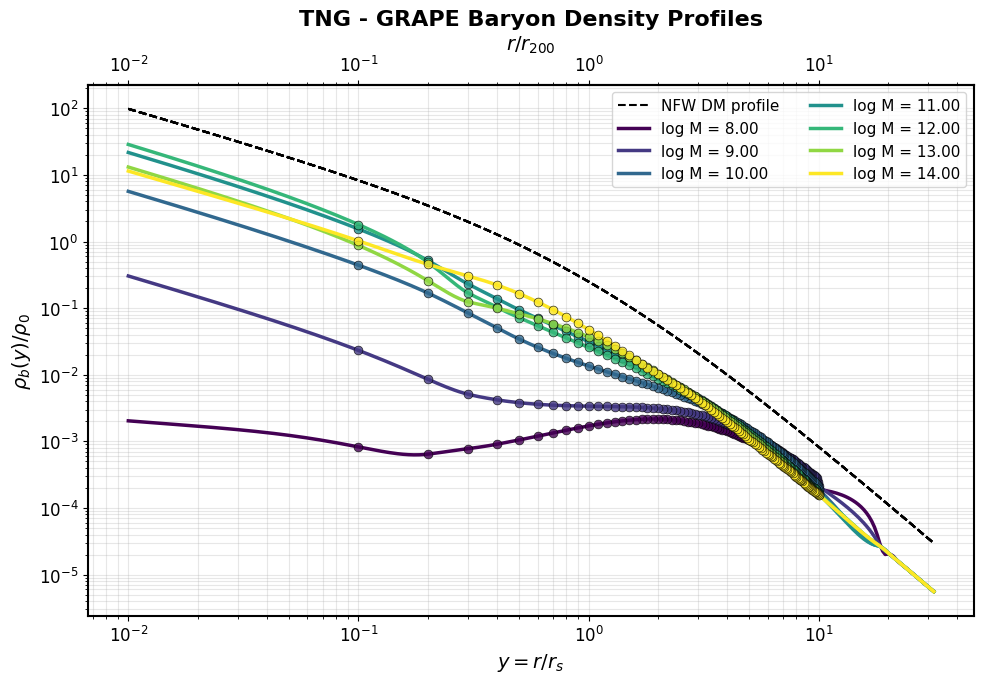


Plotting SIMBA baryon density profiles...


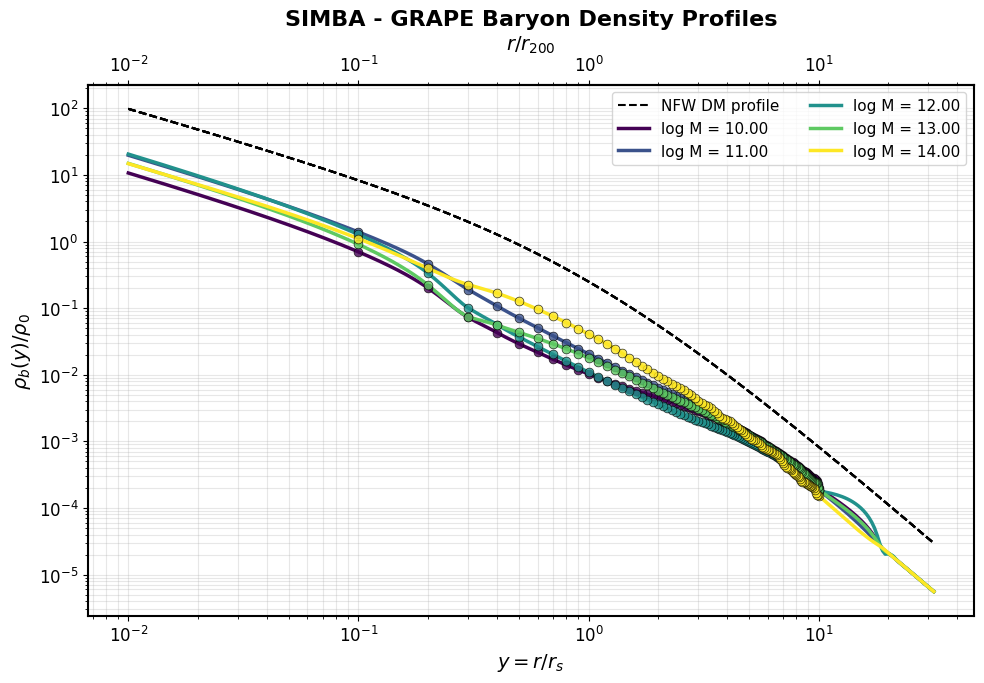


Plotting EAGLE baryon density profiles...


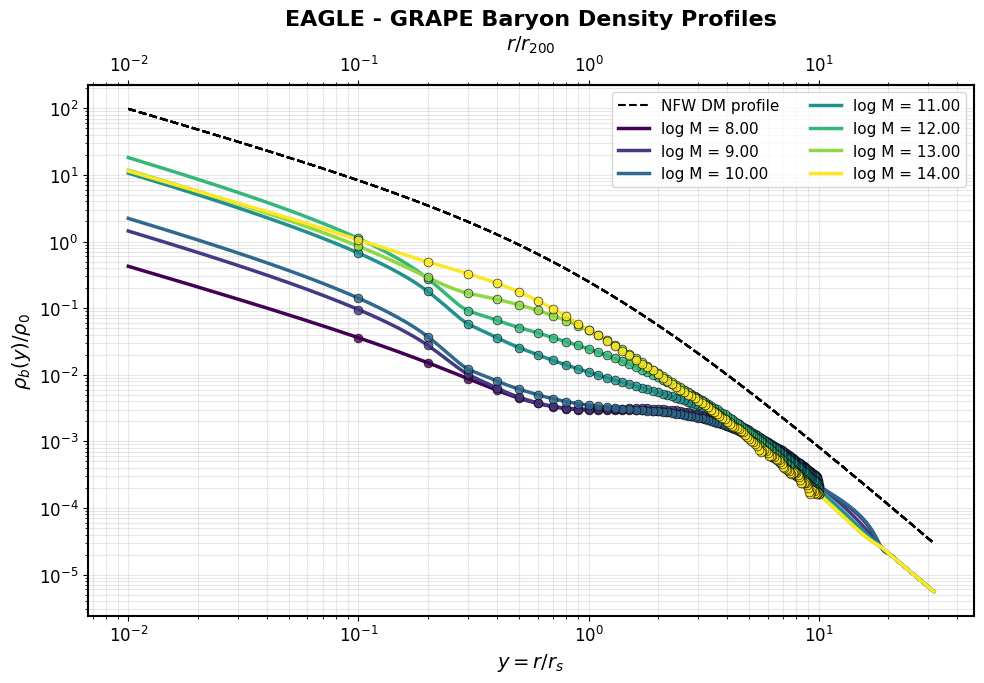

In [35]:
# Plot baryon density profiles for each Ayromlou simulation
fig_ayromlou = {}

for sim_name in ['TNG', 'SIMBA', 'EAGLE']:
    print(f"\nPlotting {sim_name} baryon density profiles...")
    
    if sim_name not in ayromlou_densities or not ayromlou_densities[sim_name]:
        print(f"  Skipping {sim_name} - no density data available")
        continue
    
    fig, ax = plt.subplots(figsize=(10, 7))
    
    # Get halo mass indices and their values
    indices = sorted(ayromlou_densities[sim_name].keys())
    log_masses = [ayromlou_densities[sim_name][idx]['log_M'] for idx in indices]
    
    # Create colormap
    norm = Normalize(vmin=min(log_masses), vmax=max(log_masses))
    cmap = plt.get_cmap('viridis')
    
    # Plot each mass bin
    for idx in indices:
        data = ayromlou_densities[sim_name][idx]
        rho_b = data['rho_b']
        rho_dm = data['rho_dm']
        log_M = data['log_M']
        
        color = cmap(norm(log_M))
        ax.loglog(R_PLOT_RANGE, rho_dm, color='k', lw=1.5, ls='--', label=f'NFW DM profile' if idx == indices[0] else None)
        ax.loglog(R_PLOT_RANGE, rho_b, color=color, lw=2.5, label=f'log M = {log_M:.2f}')
        
        # Add original data points
        if idx in ayromlou_densities_at_data[sim_name]:
            data_pts = ayromlou_densities_at_data[sim_name][idx]
            ax.scatter(data_pts['r_over_rs'], data_pts['rho_b'], 
                      color=color, s=40, marker='o', edgecolors='black', linewidths=0.5, 
                      zorder=5, alpha=0.8)
    
    # Formatting
    ax.set_xlabel(r'$y = r/r_s$', fontsize=14)
    ax.set_ylabel(r'$\rho_b(y) / \rho_0$', fontsize=14)
    ax.set_title(f'{sim_name} - GRAPE Baryon Density Profiles', fontsize=16, fontweight='bold')
    ax.grid(True, which='both', alpha=0.3)
    ax.legend(loc='best', fontsize=11, ncol=2)
    
    # Add secondary x-axis for r/r_200
    secax = ax.secondary_xaxis('top', functions=(lambda x: x / CONCENTRATION, lambda x: x * CONCENTRATION))
    secax.set_xlabel(r'$r/r_{200}$', fontsize=14)
    
    plt.tight_layout()
    plt.show()
    
    fig_ayromlou[sim_name] = fig


Plotting CROCODILE baryon density profiles...

Plotting CROCODILE (fiducial)...


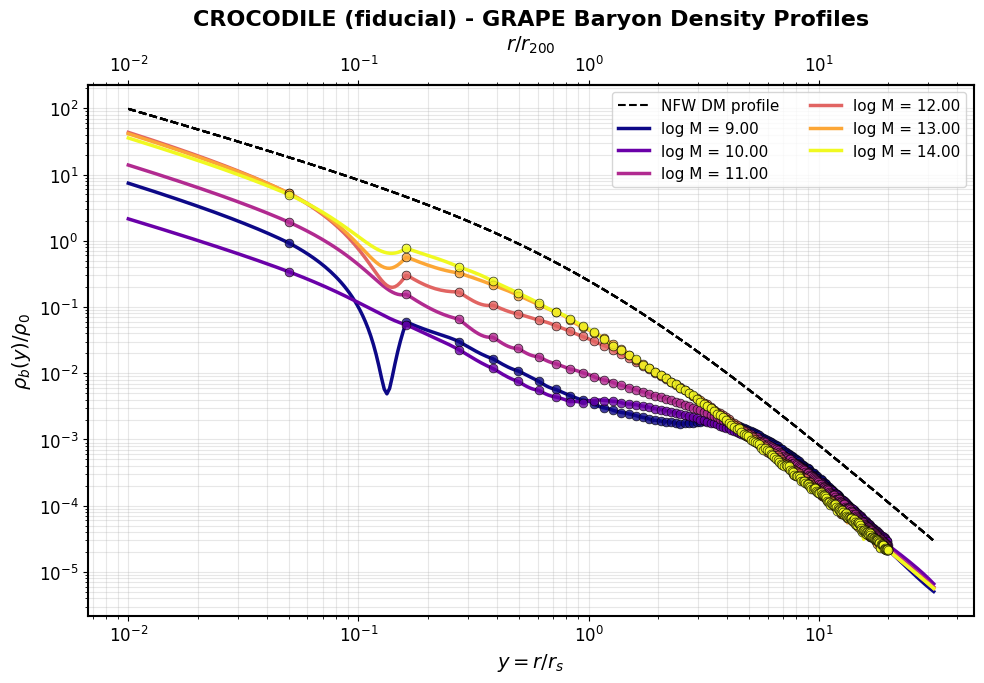


Plotting CROCODILE (no-AGN)...


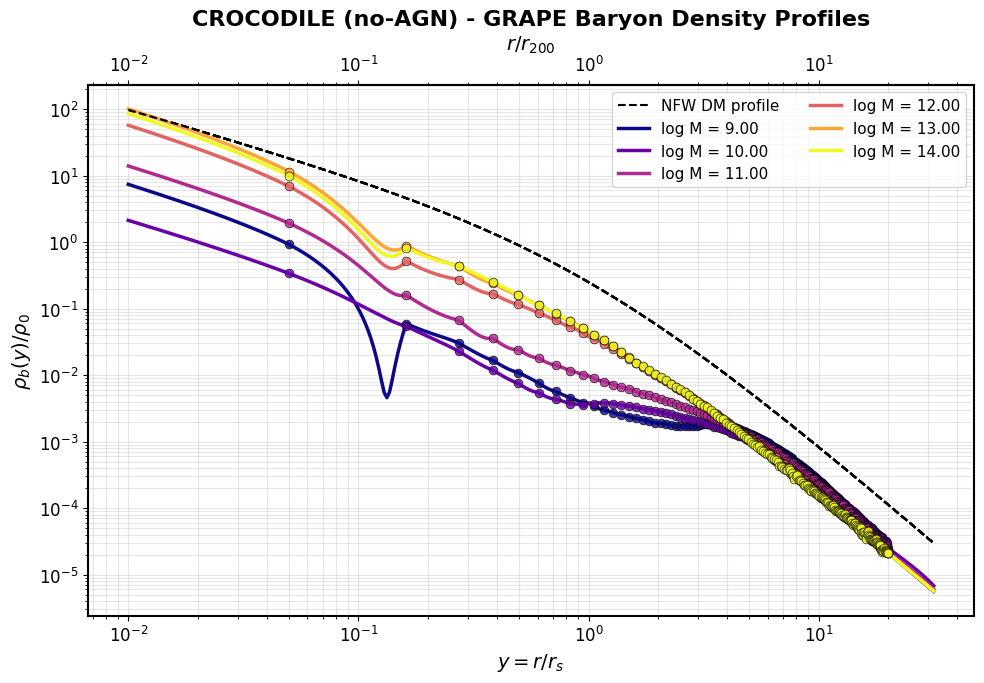

In [36]:
# Plot CROCODILE baryon density profiles
print("\n" + "="*60)
print("Plotting CROCODILE baryon density profiles...")
print("="*60)

fig_crocodile = {}

for agn_label in ['f', 'n']:
    label_str = 'fiducial' if agn_label == 'f' else 'no-AGN'
    print(f"\nPlotting CROCODILE ({label_str})...")
    
    if agn_label not in crocodile_densities or not crocodile_densities[agn_label]:
        print(f"  Skipping CROCODILE ({label_str}) - no density data available")
        continue
    
    fig, ax = plt.subplots(figsize=(10, 7))
    
    # Get halo masses
    logM_values = sorted(crocodile_densities[agn_label].keys())
    
    # Create colormap
    norm = Normalize(vmin=min(logM_values), vmax=max(logM_values))
    cmap = plt.get_cmap('plasma')
    
    # Plot each mass bin
    for logM in logM_values:
        data = crocodile_densities[agn_label][logM]
        rho_b = data['rho_b']
        rho_dm = data['rho_dm']
        
        color = cmap(norm(logM))
        ax.loglog(R_PLOT_RANGE, rho_dm, color='k', lw=1.5, ls='--', label=f'NFW DM profile' if logM == logM_values[0] else None)
        ax.loglog(R_PLOT_RANGE, rho_b, color=color, lw=2.5, label=f'log M = {logM:.2f}')
        
        # Add original data points
        if logM in crocodile_densities_at_data[agn_label]:
            data_pts = crocodile_densities_at_data[agn_label][logM]
            ax.scatter(data_pts['r_over_rs'], data_pts['rho_b'], 
                      color=color, s=40, marker='o', edgecolors='black', linewidths=0.5, 
                      zorder=5, alpha=0.8)
    
    # Formatting
    ax.set_xlabel(r'$y = r/r_s$', fontsize=14)
    ax.set_ylabel(r'$\rho_b(y) / \rho_0$', fontsize=14)
    ax.set_title(f'CROCODILE ({label_str}) - GRAPE Baryon Density Profiles', fontsize=16, fontweight='bold')
    ax.grid(True, which='both', alpha=0.3)
    ax.legend(loc='best', fontsize=11, ncol=2)
    
    # Add secondary x-axis for r/r_200
    secax = ax.secondary_xaxis('top', functions=(lambda x: x / CONCENTRATION, lambda x: x * CONCENTRATION))
    secax.set_xlabel(r'$r/r_{200}$', fontsize=14)
    
    plt.tight_layout()
    plt.show()
    
    fig_crocodile[agn_label] = fig

## Column Density Profiles for All Simulations (All Halo Masses)

Computing and plotting column density profiles for all simulations...

Processing TNG...


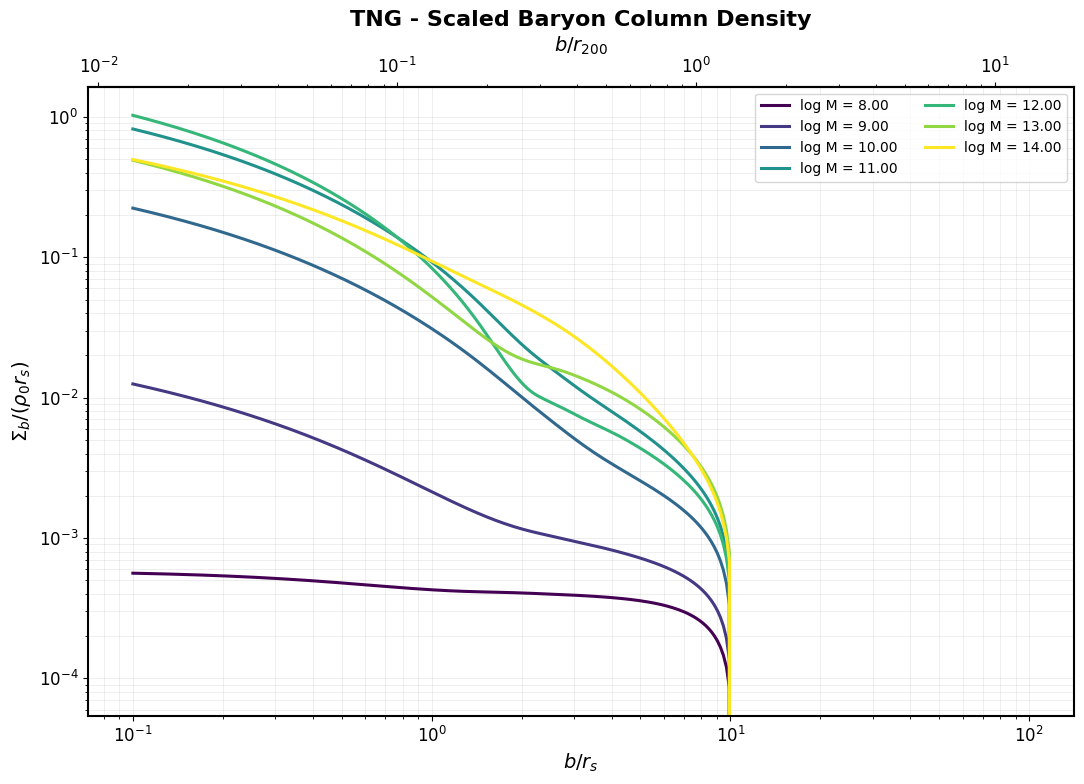


Processing SIMBA...


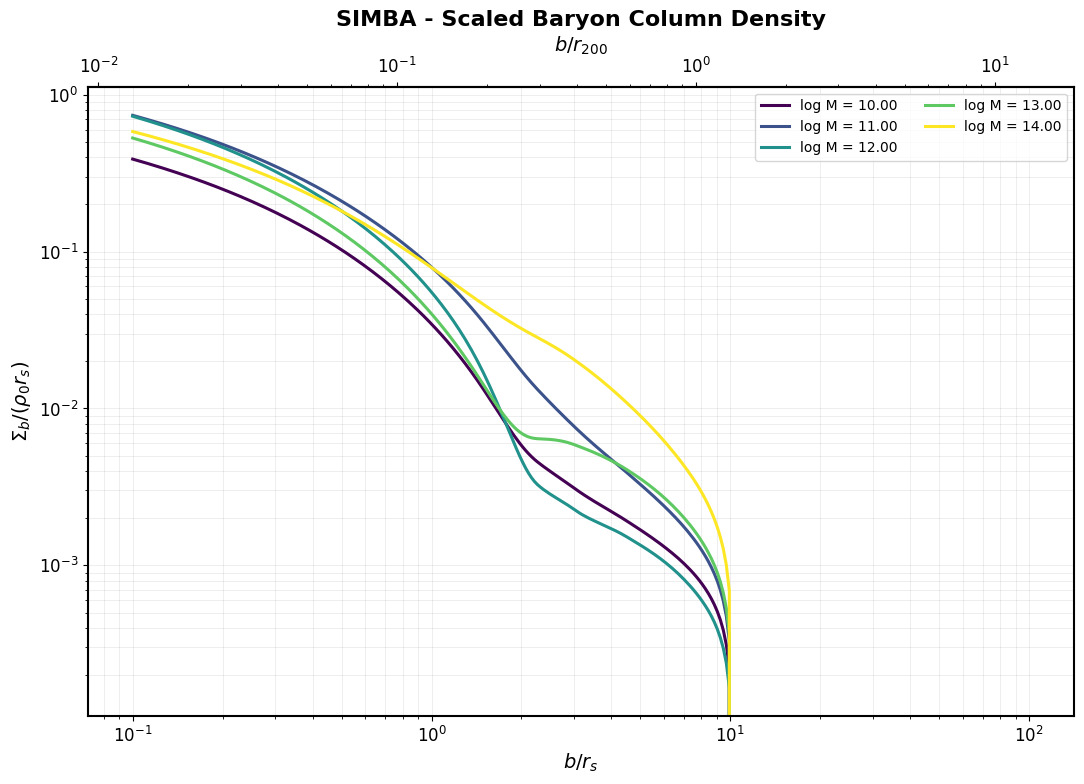


Processing EAGLE...


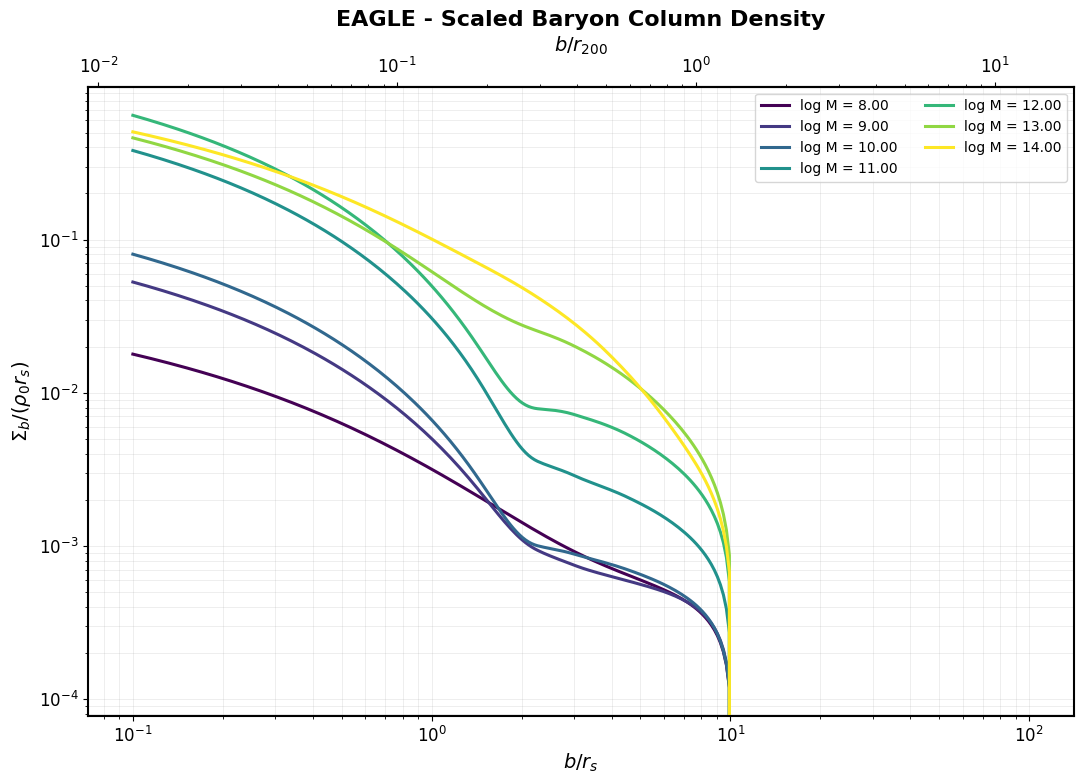


CROCODILE simulations:

Processing CROCODILE (fiducial)...


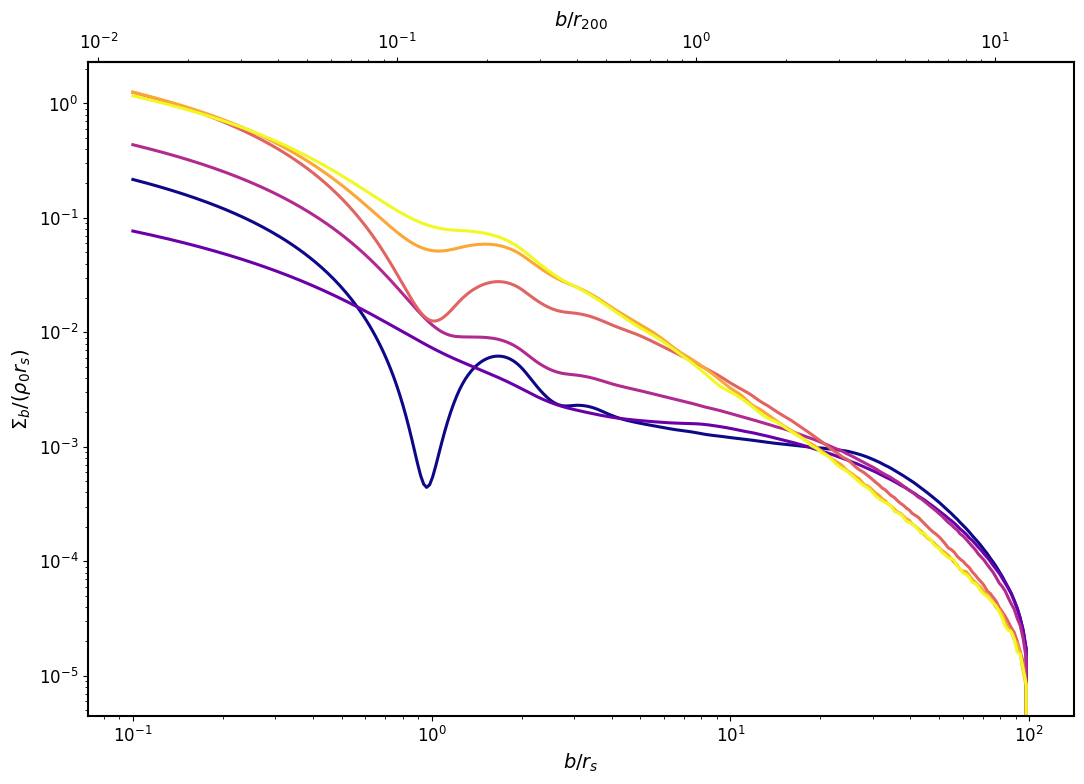


Processing CROCODILE (no-AGN)...


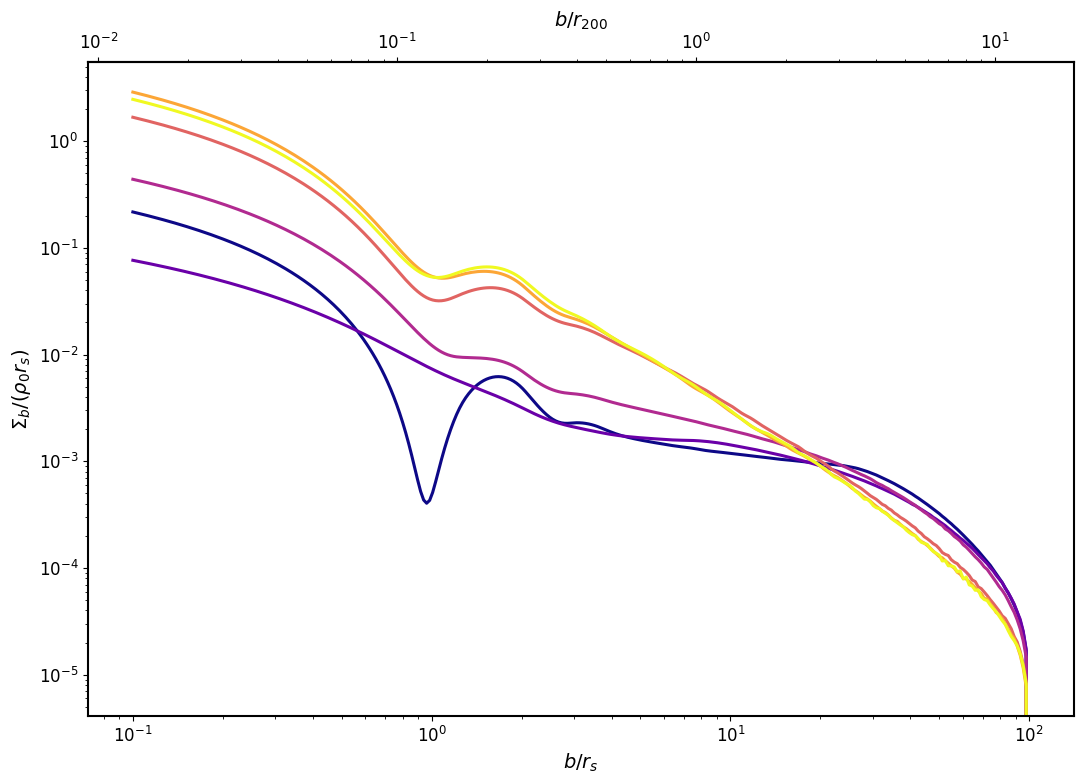

In [11]:
# Redefine R_PLOT_RANGE for column density calculations
R_PLOT_RANGE_COL = np.logspace(-1, 2, 300)

print("Computing and plotting column density profiles for all simulations...")
print("="*70)

# ========== Ayromlou simulations (TNG, SIMBA, EAGLE) ==========
fig_col_ayromlou = {}

for sim_name in ['TNG', 'SIMBA', 'EAGLE']:
    if sim_name not in grape_profiles or not grape_profiles[sim_name]:
        print(f"Skipping {sim_name}: no profiles available")
        continue
    
    print(f"\nProcessing {sim_name}...")
    fig, ax = plt.subplots(figsize=(11, 8))
    
    # Get halo mass indices and their log masses
    indices = sorted(grape_profiles[sim_name].keys())
    log_masses = [grape_profiles[sim_name][idx]['log_M_halo'] for idx in indices]
    
    # Create colormap
    norm = Normalize(vmin=min(log_masses), vmax=max(log_masses))
    cmap = plt.get_cmap('viridis')
    
    # Loop through each halo mass bin
    for idx in indices:
        profile_data = grape_profiles[sim_name][idx]
        profile = profile_data['profile']
        log_M = profile_data['log_M_halo']
        
        # Exact calculation from previous cell
        impact_params = R_PLOT_RANGE_COL * profile.r_s
        R_trunc = R_PLOT_RANGE_COL[200] * profile.r_s
        column_density = profile.column_density(impact_params, R_trunc=R_trunc)
        
        # Scale column density
        scaled_col_dens = column_density / profile.rho_0 / profile.r_s
        
        # Plot in loglog
        color = cmap(norm(log_M))
        ax.loglog(R_PLOT_RANGE_COL, scaled_col_dens, color=color, lw=2.2, 
                    label=f'log M = {log_M:.2f}')
    
    # Formatting
    ax.set_xlabel(r'$b / r_s$', fontsize=14)
    ax.set_ylabel(r'$\Sigma_b / (\rho_0 r_s)$', fontsize=14)
    ax.set_title(f'{sim_name} - Scaled Baryon Column Density', fontsize=16, fontweight='bold')
    ax.grid(True, which='both', alpha=0.3, linestyle='-', linewidth=0.5)
    ax.legend(loc='best', fontsize=10, ncol=2)
    
    # Add secondary x-axis for r/r_200
    secax = ax.secondary_xaxis('top', functions=(lambda x: x / CONCENTRATION, lambda x: x * CONCENTRATION))
    secax.set_xlabel(r'$b / r_{200}$', fontsize=14)
    
    plt.tight_layout()
    plt.show()
    fig_col_ayromlou[sim_name] = fig

# ========== CROCODILE simulations (fiducial and no-AGN) ==========
fig_col_crocodile = {}

print("\n" + "="*70)
print("CROCODILE simulations:")

for agn_label in ['f', 'n']:
    label_str = 'fiducial' if agn_label == 'f' else 'no-AGN'
    
    if agn_label not in crocodile_grape_profiles or not crocodile_grape_profiles[agn_label]:
        print(f"Skipping CROCODILE ({label_str}): no profiles available")
        continue
    
    print(f"\nProcessing CROCODILE ({label_str})...")
    fig, ax = plt.subplots(figsize=(11, 8))
    
    # Get halo mass values
    logM_values = sorted(crocodile_grape_profiles[agn_label].keys())
    
    # Create colormap
    norm = Normalize(vmin=min(logM_values), vmax=max(logM_values))
    cmap = plt.get_cmap('plasma')
    
    # Loop through each halo mass bin
    for logM in logM_values:
        profile_data = crocodile_grape_profiles[agn_label][logM]
        profile = profile_data['profile']
        
        # Exact calculation from previous cell
        impact_params = R_PLOT_RANGE_COL * profile.r_s
        R_trunc = R_PLOT_RANGE_COL[-1] * profile.r_s
        column_density = profile.column_density(impact_params, R_trunc=R_trunc)
        
        # Scale column density
        scaled_col_dens = column_density / profile.rho_0 / profile.r_s
        
        # Plot in loglog
        color = cmap(norm(logM))
        ax.loglog(R_PLOT_RANGE_COL, scaled_col_dens, color=color, lw=2.2, 
                    label=f'log M = {logM:.2f}')

    
    # Formatting
    ax.set_xlabel(r'$b / r_s$', fontsize=14)
    ax.set_ylabel(r'$\Sigma_b / (\rho_0 r_s)$', fontsize=14)
    # Add secondary x-axis for r/r_200
    secax = ax.secondary_xaxis('top', functions=(lambda x: x / CONCENTRATION, lambda x: x * CONCENTRATION))
    secax.set_xlabel(r'$b / r_{200}$', fontsize=14)

    
    fig_col_crocodile[agn_label] = fig

    plt.tight_layout()

    plt.show()